# RGM Copilot — Phase 1: Stockout-Risk Classification

**Goal:** Predict, *before the day's sales happen*, whether a region/channel/SKU combination is at
risk of stocking out — so supply chain/RGM teams can act ahead of time rather than discover it
after the fact.

**A key modeling discipline applied here: avoiding data leakage.**
The raw dataset contains columns like `on_hand_after` and `demand_units` that are only known
*after* the stockout has already happened — using them directly would let the model "cheat" by
seeing the outcome before predicting it. Instead, this notebook only uses information genuinely
available **before the day starts**:
- Yesterday's closing inventory (`on_hand_opening`) — a legitimate morning stock-check feature
- The **forecasted demand** from the demand forecasting model (notebook 2) — reusing that model's
  output as an input here directly mirrors a real production pipeline, where forecasting feeds
  into downstream risk models
- Lag/rolling sales history, lead time, promo calendar, pricing, calendar features

This notebook:
1. Engineers leakage-safe features
2. Trains an XGBoost classifier with class-imbalance handling (stockouts are only ~4.6% of days)
3. Evaluates with ROC-AUC, PR-AUC, precision/recall — **not accuracy**, which would be misleading
   on this imbalanced a target
4. Discusses the business cost asymmetry (missing a stockout is worse than a false alarm) and
   tunes the decision threshold accordingly
5. Saves the model for the GenAI layer (notebook 4)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score, confusion_matrix
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load data and rebuild features

Same lag/rolling/calendar features as notebook 2, plus the leakage-safe inventory and demand-forecast features described above.

In [2]:
df = pd.read_csv("../data/rgm_copilot_dataset.csv", parse_dates=["date"])
df = df.sort_values(["region", "channel", "sku", "date"]).reset_index(drop=True)

group_cols = ["region", "channel", "sku"]
df["dow"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["doy"] = df["date"].dt.dayofyear
df["is_weekend"] = (df["dow"] >= 4).astype(int)
df["doy_sin"] = np.sin(2 * np.pi * df["doy"] / 365)
df["doy_cos"] = np.cos(2 * np.pi * df["doy"] / 365)

g = df.groupby(group_cols, group_keys=False)
for lag in [1, 7, 14, 28]:
    df[f"lag_{lag}"] = g["units_sold"].shift(lag)
for win in [7, 14, 28]:
    df[f"roll_mean_{win}"] = g["units_sold"].apply(lambda s: s.shift(1).rolling(win).mean())
    df[f"roll_std_{win}"] = g["units_sold"].apply(lambda s: s.shift(1).rolling(win).std())

# Proxy for "opening stock this morning" = yesterday's closing inventory.
# This is genuinely knowable before the day starts (a morning stock check) — not leakage.
df["on_hand_opening"] = g["on_hand_after"].shift(1)

for col in ["region", "channel", "sku"]:
    df[col + "_code"] = df[col].astype("category").cat.codes

df_model = df.dropna().reset_index(drop=True)
print("Rows after dropping warm-up NaNs:", df_model.shape)

Rows after dropping warm-up NaNs: (112320, 32)


## 2. Reuse the demand forecasting model as a feature

This is the pipeline integration point: the stockout classifier consumes the forecasting model's
predictions as an input, exactly like a real production system would chain models together.

In [3]:
fc_model = joblib.load("../models/demand_forecast_model.pkl")
fc_features = joblib.load("../models/demand_forecast_features.pkl")
df_model["predicted_demand"] = fc_model.predict(df_model[fc_features])
print("Demand forecast feature added.")

C:\Users\20155\anaconda3\envs\rgm\Lib\pickle.py:1718: UserWarning: [00:52:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


Demand forecast feature added.


## 3. Time-based train/test split (same cutoff as notebook 2)

In [4]:
feature_cols = [
    "dow", "month", "is_weekend", "doy_sin", "doy_cos",
    "lag_1", "lag_7", "lag_14",
    "roll_mean_7", "roll_std_7", "roll_std_14",
    "on_hand_opening", "predicted_demand", "lead_time_days",
    "on_promo", "unit_price",
    "region_code", "channel_code", "sku_code",
]
target_col = "stockout_flag"

split_date = "2024-07-01"
train = df_model[df_model["date"] < split_date]
test = df_model[df_model["date"] >= split_date]

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print(f"Train stockout rate: {y_train.mean():.2%}   ({y_train.sum():,.0f} stockout days)")
print(f"Test stockout rate:  {y_test.mean():.2%}   ({y_test.sum():,.0f} stockout days)")

Train stockout rate: 4.50%   (3,736 stockout days)
Test stockout rate:  5.63%   (1,648 stockout days)


## 4. Train XGBoost with class-imbalance handling

Stockouts are rare (~4-6% of rows). Without correction, a classifier could get 95%+ "accuracy"
by just predicting "no stockout" every time — which would be a useless model.
`scale_pos_weight` tells XGBoost to penalize missing the minority class more heavily.

In [5]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

clf = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
)
clf.fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

scale_pos_weight: 21.23


## 5. Evaluation — why accuracy is the wrong metric here

With a ~95/5 class split, accuracy can look great while still missing most real stockouts.
We use **ROC-AUC**, **PR-AUC** (more informative under imbalance), and the full classification
report (precision/recall/F1) instead.

In [6]:
roc_auc = roc_auc_score(y_test, proba)
pr_auc = average_precision_score(y_test, proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC (average precision): {pr_auc:.4f}\n")
print(classification_report(y_test, pred, digits=3, target_names=["No stockout", "Stockout"]))

ROC-AUC: 0.9944
PR-AUC (average precision): 0.9155

              precision    recall  f1-score   support

 No stockout      0.996     0.976     0.986     27632
    Stockout      0.702     0.936     0.802      1648

    accuracy                          0.974     29280
   macro avg      0.849     0.956     0.894     29280
weighted avg      0.980     0.974     0.976     29280



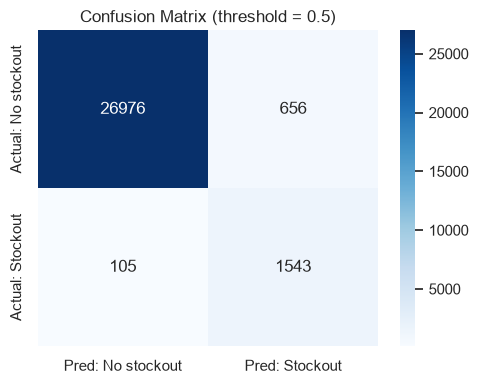

In [7]:
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No stockout", "Pred: Stockout"],
            yticklabels=["Actual: No stockout", "Actual: Stockout"], ax=ax)
ax.set_title("Confusion Matrix (threshold = 0.5)")
plt.tight_layout()
plt.show()

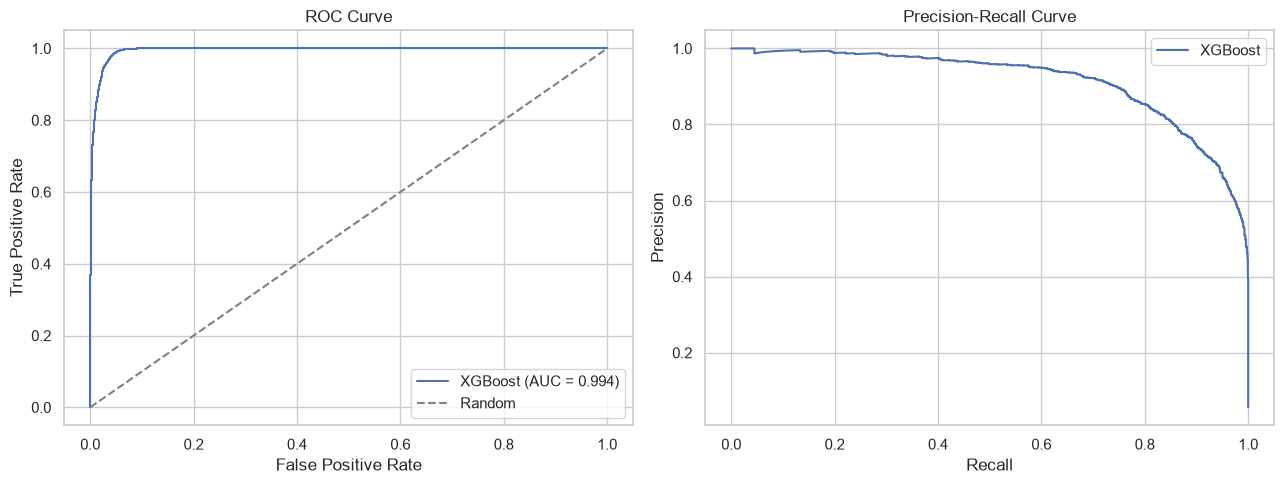

In [8]:
# Computed manually (rather than via Display.from_predictions) so this works
# across scikit-learn versions, since that convenience API was only added in
# more recent sklearn releases.
from sklearn.metrics import roc_curve, auc, precision_recall_curve as pr_curve_fn

fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc_val = auc(fpr, tpr)

prec_curve, rec_curve, _ = pr_curve_fn(y_test, proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc_val:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(rec_curve, prec_curve, label="XGBoost")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Business framing: which error costs more?

- **False negative** (predicted "fine", actual stockout): a shelf goes empty, a sale is lost, and
  in a real RGM context this can mean lost trade-partner trust — the costlier mistake.
- **False positive** (predicted "risk", actual fine): worst case, a precautionary reorder happens
  a bit early — a small, recoverable cost.

Given that asymmetry, it's reasonable to **prioritize recall over precision** — i.e. lower the
decision threshold below 0.5 so fewer real stockouts slip through, accepting more false alarms
in exchange.

In [9]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, proba)

# find the threshold that achieves at least 95% recall, with best precision at that point
target_recall = 0.95
idx_candidates = np.where(recalls[:-1] >= target_recall)[0]
if len(idx_candidates) > 0:
    idx = idx_candidates[-1]
    chosen_threshold = thresholds[idx]
    print(f"Threshold for >= {target_recall:.0%} recall: {chosen_threshold:.3f}")
    print(f"At this threshold -> precision: {precisions[idx]:.3f}, recall: {recalls[idx]:.3f}")

    pred_highrecall = (proba >= chosen_threshold).astype(int)
    print("\n", classification_report(y_test, pred_highrecall, digits=3,
                                        target_names=["No stockout", "Stockout"]))
else:
    print("Target recall not reachable in this threshold sweep.")

Threshold for >= 95% recall: 0.408
At this threshold -> precision: 0.673, recall: 0.950

               precision    recall  f1-score   support

 No stockout      0.997     0.972     0.985     27632
    Stockout      0.673     0.950     0.788      1648

    accuracy                          0.971     29280
   macro avg      0.835     0.961     0.886     29280
weighted avg      0.979     0.971     0.974     29280



## 7. Feature importance

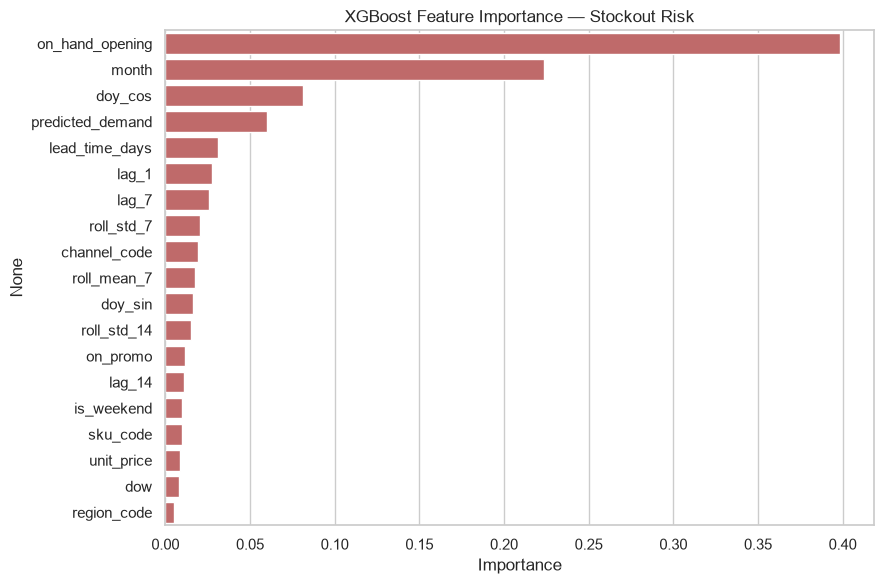

In [10]:
importance = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=importance.values, y=importance.index, ax=ax, color="indianred")
ax.set_title("XGBoost Feature Importance — Stockout Risk")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. Save the model and a risk lookup table

This feeds the GenAI layer in notebook 4 — so the assistant can answer questions like
"which SKUs are at risk of stockout this week?" with real model output.

In [11]:
joblib.dump(clf, "../models/stockout_risk_model.pkl")
joblib.dump(feature_cols, "../models/stockout_risk_features.pkl")

risk_lookup = test[["date", "region", "channel", "sku"]].copy()
risk_lookup["stockout_actual"] = y_test.values
risk_lookup["stockout_risk_score"] = proba
risk_lookup.to_csv("../models/stockout_risk_lookup.csv", index=False)

print("Saved model files to ../models/")
risk_lookup.sort_values("stockout_risk_score", ascending=False).head(10)

Saved model files to ../models/


,date,region,channel,sku,stockout_actual,stockout_risk_score
51076,2024-07-14,Greater Cairo,HoReCa,Cola Regular 330ml,1,0.999893
63715,2024-07-17,Greater Cairo,Traditional Trade,Energy Drink 250ml,1,0.999666
53185,2024-07-17,Greater Cairo,HoReCa,Iced Tea 500ml,1,0.999465
13892,2024-08-05,Alexandria & North Coast,Modern Trade,Iced Tea 500ml,1,0.999268
53206,2024-08-07,Greater Cairo,HoReCa,Iced Tea 500ml,1,0.999267
58802,2024-07-18,Greater Cairo,Modern Trade,Iced Tea 500ml,1,0.999234
53184,2024-07-16,Greater Cairo,HoReCa,Iced Tea 500ml,1,0.999141
55316,2024-08-11,Greater Cairo,HoReCa,Orange Soda 330ml,1,0.999089
15261,2024-07-01,Alexandria & North Coast,Modern Trade,Lemon Soda 330ml,1,0.999064
97437,2024-08-12,Upper Egypt,HoReCa,Energy Drink 250ml,1,0.999038
